# Steel TUR — Pipeline V2
**Türkiye — Steel Rebar FOB Turkey (STCBM00)**

V2 protocol (validated in experiments M1–M5):
- Temporal **65/15/20** split (train/validation/test); Optuna and Top-3 decided on validation only; test set untouched.
- **One-shot forecasting with ocl = h** (`historical_forecasts`, h ∈ {1, 5, 21, 66}), statistical baselines included.
- Permanent benchmarks: **naive-h** and **drift-h**; headline metric: RelMAE.
- Ensembles with a **temporal gap**; multi-seed with reported dispersion; DM tests (NW and stride = h).
- Error exports compatible with the VaR/FRI layer.


In [1]:
# ============================================
# Config
# ============================================
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import warnings; warnings.filterwarnings("ignore")
import logging; logging.disable(logging.CRITICAL)
import torch
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pipeline_v2p as pv2

CC       = "TUR"
TARGET   = "tur_bmk"
DATASET  = "dataset/ds_steel.xlsx"
H_LIST   = [5]
SEEDS    = [42, 43, 44]     # per-model seed dispersion is reported
N_TRIALS = 50               # Optuna on validation (cache: result/v2_hp_tur.xlsx)
FORCE_TUNE = False          # True => ignore cache and re-tune

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})


## 1. Preprocessing, split and data quality


n=5006 | interp_share=0.033 | staleness=0.629
train: ... -> 2019-10-10 (3253 obs)
val:   ... -> 2022-08-26 (751 obs)
test:  ... -> 2026-06-30 (1002 obs)


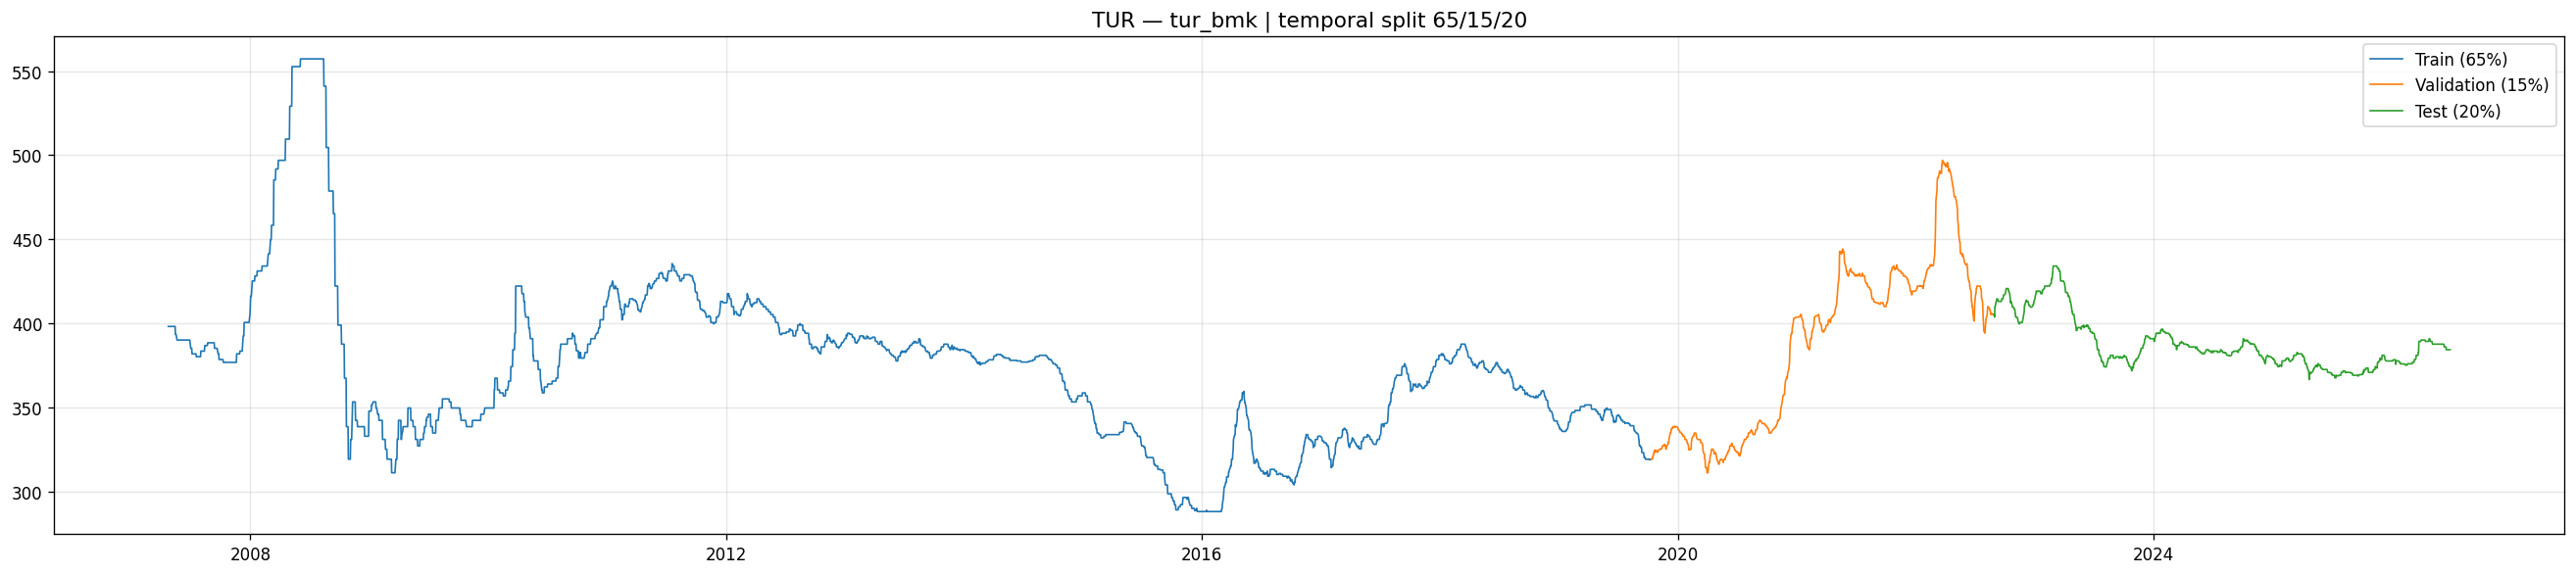

In [2]:
d = pv2.preprocess(TARGET, DATASET)
print(f"n={d['n']} | interp_share={d['interp_share']:.3f} | staleness={d['stale_raw']:.3f}")
print(f"train: ... -> {d['train_o'].end_time().date()} ({d['t1']} obs)")
print(f"val:   ... -> {d['val_o'].end_time().date()} ({d['t2']-d['t1']} obs)")
print(f"test:  ... -> {d['test_o'].end_time().date()} ({d['n']-d['t2']} obs)")
pv2.plot_split_overview(d, CC)


## 2. Full run

`run_country` performs, for each h: Optuna on validation (cached), refit on
train+validation with multiple seeds, `historical_forecasts` on the test set,
statistical baselines under the same protocol, naive/drift benchmarks,
ensembles with the validation Top-3, metrics + DM tests, and exports
`result/v2_result_steel_*.xlsx`.

⚠️ First run (no hp cache): several hours. Re-runs use the cache.


In [3]:
res = pv2.run_country(CC, TARGET, DATASET, h_list=H_LIST, seeds=SEEDS,
                      n_trials=N_TRIALS, force_tune=FORCE_TUNE)
summary = res["summary"]


TUR: preprocessing (65/15/20 split)...
  n=5006 | train until 2019-10-10 | val until 2022-08-26 | test until 2026-06-30
  interp_share=0.033 | staleness=0.629

----- TUR | h=5 -----
  [RNN|h=5] Optuna (50 trials on validation, pinball)...
  [RNN|h=5] val_pinball=1.36960 (2044.6s)
  [RNN|h=5] test pinball=0.49447 | SMAPE(med)=0.4746 (±0.00173 pb across 3 seeds)
  [Transformer|h=5] Optuna (50 trials on validation, pinball)...
  [Transformer|h=5] val_pinball=1.53581 (8699.9s)
  [Transformer|h=5] test pinball=0.53114 | SMAPE(med)=0.4983 (±0.06636 pb across 3 seeds)
  [N-HiTS|h=5] Optuna (50 trials on validation, pinball)...
  [N-HiTS|h=5] val_pinball=1.33707 (2389.8s)
  [N-HiTS|h=5] test pinball=0.56477 | SMAPE(med)=0.5290 (±0.01062 pb across 3 seeds)
  [DLinear|h=5] Optuna (50 trials on validation, pinball)...
  [DLinear|h=5] val_pinball=1.07225 (1102.9s)
  [DLinear|h=5] test pinball=0.55080 | SMAPE(med)=0.4082 (±0.01540 pb across 3 seeds)
  [TCN|h=5] Optuna (50 trials on validation, pinb

d:\dl_darts\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  [ARIMA] ok (26.9s)
  [ExpSmoothing] FAILED: LocalForecastingModel does not support historical forecasting with `retrain` set to `False`. For now, this is only supported with GlobalForecastingModels such as TorchForecastingModels. For more information, read the documentation for `retrain` in `historical_forecasts()`
  [LinearRegression] ok (0.3s)
  Top-3 (validation, pinball): ['TCN', 'DLinear', 'TSMixer']
  ✔ h=5 checkpointed (result/v2p_ckpt_tur.xlsx)

✅ result/v2p_result_steel_tur.xlsx saved


## 3. Result tables


In [4]:
for h in H_LIST:
    blk = summary[summary.h == h].sort_values("RelMAE_vs_NaiveH")
    print(f"\n===== {CC} | h={h} =====")
    print(blk[["Model", "SMAPE", "RMSE", "MASE", "Cover90", "PB05", "PB95",
               "Winkler90", "RelMAE_vs_NaiveH", "DMstride_p_one", "Seed_std_PB"]]
          .round(4).to_string(index=False))



===== TUR | h=5 =====
           Model  SMAPE   RMSE   MASE  Cover90   PB05   PB95  Winkler90  RelMAE_vs_NaiveH  DMstride_p_one  Seed_std_PB
LinearRegression 0.4046 2.2275 0.5214      NaN    NaN    NaN        NaN            0.9257          0.0010          NaN
         DLinear 0.4082 2.2445 0.5268   1.0000 0.4182 0.4346    17.0551            0.9355          0.0001       0.0154
           ARIMA 0.4097 2.2728 0.5294      NaN    NaN    NaN        NaN            0.9400          0.0000          NaN
     EnsDynSMAPE 0.4205 2.3042 0.5422   0.9850 0.2944 0.3090    12.0670            0.9628          0.0011          NaN
         EnsMean 0.4226 2.3125 0.5448   0.9830 0.2908 0.3067    11.9499            0.9674          0.0016          NaN
   EnsPinballDyn 0.4240 2.3155 0.5466   0.9820 0.2852 0.2995    11.6935            0.9705          0.0024          NaN
          NaiveH 0.4360 2.4935 0.5632      NaN    NaN    NaN        NaN            1.0000             NaN          NaN
             TCN 0.4370 2

## 4. Plots


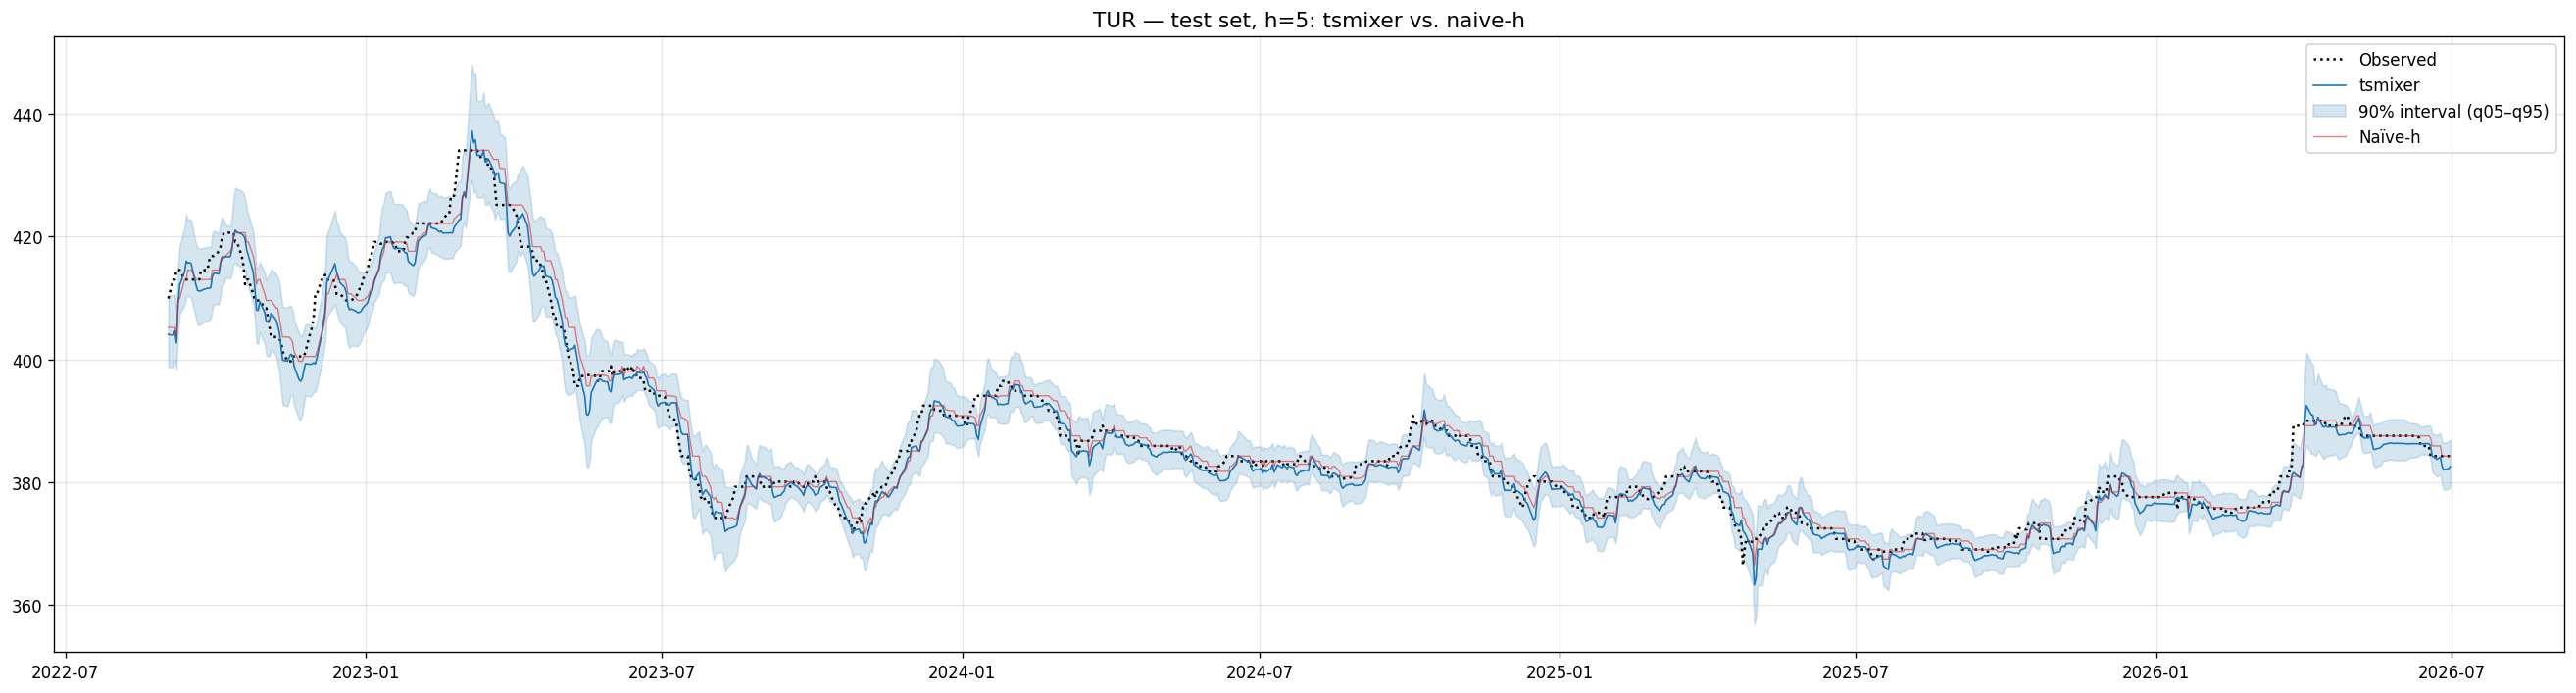

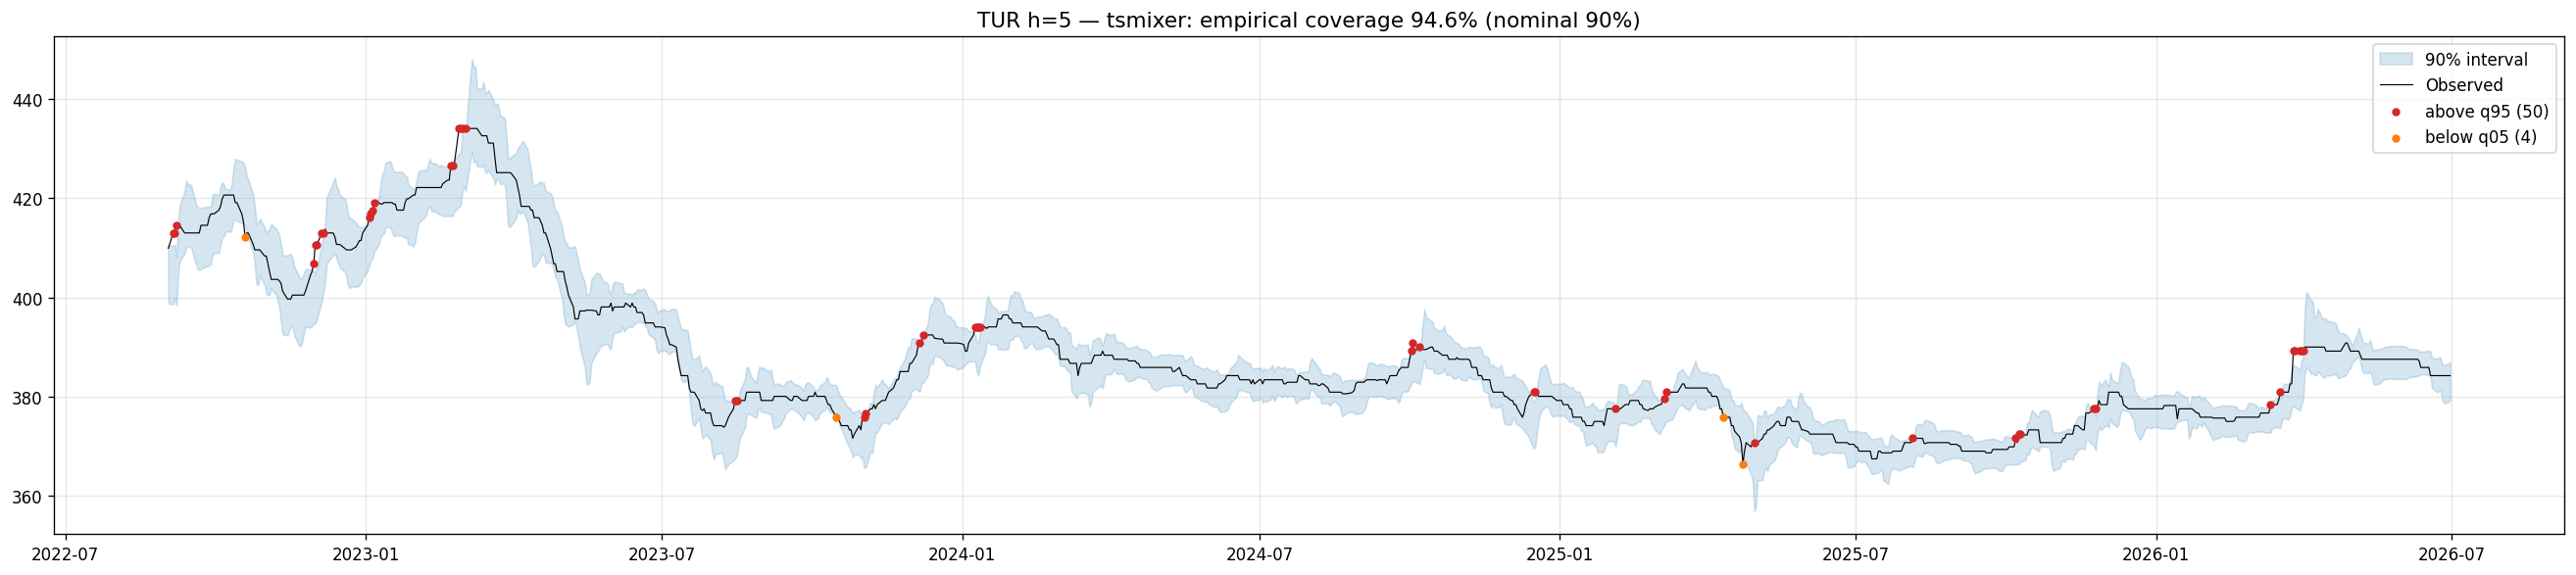

Best (rank_prob) at h=5: TSMixer


In [5]:
# Best candidate (RelMAE) vs naive-h at the longest horizon
h_show = H_LIST[0]   # h=5

rankp = res.get("rank_prob")
if rankp is not None and len(rankp):
    best = rankp[rankp.h == h_show].sort_values("TOTAL_scr", ascending=False).iloc[0]["Model"]
else:
    blk = summary[(summary.h == h_show) & (~summary.Model.isin(["NaiveH", "DriftH"]))]
    best = blk.sort_values("PB95").iloc[0]["Model"]

pfx = pv2.MODEL_PREFIX.get(best, best)
pv2.plot_test_forecast(res["err_sheets"][h_show], pfx, CC, h_show)      # banda q05–q95
pv2.plot_interval_coverage(res["err_sheets"][h_show], pfx, CC, h_show)  # excedências vs. cobertura
print(f"Best (rank_prob) at h={h_show}: {best}")


## 5. Next phase

The `error_<cc>_h<h>` sheets in `result/v2_result_steel_*.xlsx` feed the
VaR/FRI layer (Kupiec/Christoffersen/DQ backtesting + dynamic Basel
Traffic-Light) in the same format as the original error sheets. The pooled
cross-market test (Fisher) runs in the consolidation notebook once all four
countries are done.

Oil ablation (M6, after updating dataset/ds_oil.xlsx through Jun/2026):
`pv2.run_country(CC, TARGET, DATASET, h_list=H_LIST, seeds=SEEDS,
n_trials=N_TRIALS, oil_path="dataset/ds_oil.xlsx", tag="oil")` — reuses the
hp cache, writes to `v2_result_steel_*_oil.xlsx`.
